# MAE-HID SSL Ablation Visualization

Same structure as `consolidated_visualization.ipynb` (the HAR notebook), adapted for HumanIdentification's mixed evaluation schema:

- **Closed-set splits** (`test_id`, `test_cross_env`) -- all identities present are also in `train_id`'s `label_map`, so KNN/LP/MLP probe accuracy work normally, same as HAR.
- **Open-set splits** (`test_cross_device`, `test_cross_user`) -- contain identities never seen in `train_id` (e.g. `U02`). These use Rank-1 retrieval accuracy and verification AUC/EER instead -- see `train_mae_hid.py`'s docstring for why a closed-set classifier structurally can't be used here.
- **`test_cross_user` is a degenerate case** -- it contains only ONE identity (`U02`), so Rank-1 retrieval is *trivially* 100% regardless of embedding quality, and verification AUC/EER are undefined (no different-identity pairs exist). Every plot below flags this explicitly rather than silently showing a misleading 100%.

In [1]:
import json
import glob
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

## Paths -- point these at your actual server paths

In [2]:
RESULTS_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results/mae_hid")
FIG_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/figs/mae_hid")
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLOSED_SPLITS = ['test_id', 'test_cross_env']
OPENSET_SPLITS = ['test_cross_device', 'test_cross_user']
ALL_SPLITS = CLOSED_SPLITS + OPENSET_SPLITS
SPLIT_LABELS = {
    'test_id': 'ID (in-distribution)',
    'test_cross_env': 'Cross-Env (closed-set)',
    'test_cross_device': 'Cross-Device (open-set)',
    'test_cross_user': 'Cross-User (open-set, trivial)',
}

## Shared loading & grouping utilities

Same pattern as the HAR notebook's `load_matching_results` / `group_by` -- filters `results/mae_hid/*.json` by an `args` dict, groups matching files by a key function (e.g. `mask_ratio`, `mask_strategy`, `patch_h`).

In [3]:
def load_matching_results(results_dir, filters, debug=False):
    """Scans results_dir for *.json files whose saved args match every key in `filters`.
    Returns a list of loaded result dicts. debug=True prints a [match]/[skip: reason] line
    per file -- the fastest way to find out why an expected file wasn't picked up."""
    matched = []
    for path in sorted(results_dir.glob("*.json")):
        try:
            with open(path) as f:
                result = json.load(f)
        except (json.JSONDecodeError, UnicodeDecodeError):
            if debug:
                print(f"[skip: unreadable] {path.name}")
            continue
        args = result.get('args', {})
        mismatch = None
        for key, val in filters.items():
            if args.get(key) != val:
                mismatch = f"{key}={args.get(key)!r} != {val!r}"
                break
        if mismatch:
            if debug:
                print(f"[skip: {mismatch}] {path.name}")
            continue
        if debug:
            print(f"[match] {path.name}")
        matched.append(result)
    return matched


def group_by(results, key_fn):
    """Groups a list of result dicts by key_fn(result['args']) or key_fn(result) --
    tries the args dict first, falls back to the whole result. Returns {key: [results]}."""
    groups = defaultdict(list)
    for r in results:
        try:
            key = key_fn(r)
        except (KeyError, TypeError):
            continue
        groups[key].append(r)
    return dict(groups)


def get_checkpoints(result):
    """Sorted list of eval checkpoint keys ('epoch_50', 'epoch_100', ...) by epoch number."""
    return sorted(result['evals'].keys(), key=lambda k: int(k.split('_')[1]))


def get_layers(result, ckpt=None):
    """Available layer keys ('layer_1', 'layer_3', ...) at a given checkpoint (default: last)."""
    ckpt = ckpt or get_checkpoints(result)[-1]
    return sorted(result['evals'][ckpt].keys(), key=lambda k: int(k.split('_')[1]))

## Shared plotting utilities

Two families: closed-set (accuracy-based, same shape as HAR) and open-set (Rank-1 / verification AUC, HID-specific). Both auto-detect `n` per group from how many result files matched, and both print a `[warn]` if a group's `n` looks off (missing seed, stray duplicate, etc.) -- same discipline as the HAR notebook.

In [4]:
GROUP_COLORS = {
    # mask ratio
    0.5: '#0EA5E9', 0.75: '#22C55E', 0.875: '#EAB308', 0.95: '#EF4444',
    # mask strategy
    'random': '#0EA5E9', 'time': '#F97316', 'freq': '#22C55E', 'mixed': '#EAB308', '2d': '#7C3AED',
    # patch size
    11: '#0EA5E9', 13: '#22C55E', 15: '#EAB308', 17: '#F97316', 19: '#EF4444', 21: '#7C3AED',
}


def _final_layer_evals(result, layer=None):
    """Returns the eval dict at the LAST checkpoint, deepest available layer (or a given
    layer if specified) -- e.g. result['evals']['epoch_150']['layer_12']."""
    final_ckpt = get_checkpoints(result)[-1]
    layers = get_layers(result, final_ckpt)
    layer_key = f"layer_{layer}" if layer else layers[-1]
    if layer_key not in result['evals'][final_ckpt]:
        return None, None
    return result['evals'][final_ckpt][layer_key], layer_key

In [5]:
def plot_closed_set_bar_by_group(groups, fig_dir, filename, title, metric='lp_acc',
                                  colors=None, group_label_fmt="{k}", layer=None):
    """Bar chart over CLOSED_SPLITS (test_id, test_cross_env), grouped bars per config
    value (e.g. per mask_ratio). metric: 'knn_acc' | 'lp_acc' | 'mlp_acc' (or the _f1
    variants). Mirrors plot_final_accuracy_by_group from the HAR notebook."""
    keys = sorted(groups.keys(), key=lambda k: (isinstance(k, str), k))
    x = np.arange(len(CLOSED_SPLITS))
    n_groups = len(keys)
    width = 0.8 / max(n_groups, 1)

    fig, ax = plt.subplots(figsize=(9, 6))
    for i, key in enumerate(keys):
        runs = groups[key]
        means, stds, ns = [], [], []
        for split in CLOSED_SPLITS:
            vals = []
            for r in runs:
                layer_evals, _ = _final_layer_evals(r, layer)
                if layer_evals and split in layer_evals and metric in layer_evals[split]:
                    vals.append(layer_evals[split][metric])
            means.append(np.mean(vals) if vals else 0)
            stds.append(np.std(vals) if len(vals) > 1 else 0)
            ns.append(len(vals))
        if len(set(ns)) > 1 or (ns and ns[0] not in (1, 2, 3)):
            print(f"[warn] group {key!r}: inconsistent/unusual n per split -> {dict(zip(CLOSED_SPLITS, ns))}")
        offset = (i - (n_groups - 1) / 2) * width
        color = (colors or {}).get(key)
        label = group_label_fmt.format(k=key) + f" (n={ns[0] if ns else 0})"
        bars = ax.bar(x + offset, means, width=width, yerr=stds, label=label, color=color, capsize=3)
        ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels([SPLIT_LABELS[s] for s in CLOSED_SPLITS])
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.0, 0.5))
    ax.grid(alpha=0.3, axis='y')
    fig.tight_layout()
    fig.savefig(fig_dir / filename, dpi=150, bbox_inches='tight')
    plt.show()

In [6]:
def plot_openset_bar_by_group(groups, fig_dir, filename, title, metric='verif_auc',
                               colors=None, group_label_fmt="{k}", layer=None,
                               include_trivial_split=False):
    """Bar chart over OPENSET_SPLITS. metric: 'rank1_acc' | 'verif_auc' | 'verif_eer'.
    By default EXCLUDES test_cross_user (n_identities==1, so rank1_acc is trivially 1.0 and
    verif_auc/eer are None/undefined -- plotting it would be misleading). Set
    include_trivial_split=True only if you specifically want to see/annotate that."""
    splits = OPENSET_SPLITS if include_trivial_split else ['test_cross_device']
    keys = sorted(groups.keys(), key=lambda k: (isinstance(k, str), k))
    x = np.arange(len(splits))
    n_groups = len(keys)
    width = 0.8 / max(n_groups, 1)

    fig, ax = plt.subplots(figsize=(9, 6))
    any_trivial_warned = False
    for i, key in enumerate(keys):
        runs = groups[key]
        means, stds, ns = [], [], []
        for split in splits:
            vals = []
            for r in runs:
                layer_evals, _ = _final_layer_evals(r, layer)
                if not layer_evals or split not in layer_evals:
                    continue
                d = layer_evals[split]
                if d.get('n_identities') == 1 and metric != 'rank1_acc':
                    if not any_trivial_warned:
                        print(f"[note] {split} has only 1 identity in this checkpoint -- "
                              f"'{metric}' is undefined (None) there, excluded from the mean.")
                        any_trivial_warned = True
                    continue
                v = d.get(metric)
                if v is not None:
                    vals.append(v)
            means.append(np.mean(vals) if vals else 0)
            stds.append(np.std(vals) if len(vals) > 1 else 0)
            ns.append(len(vals))
        offset = (i - (n_groups - 1) / 2) * width
        color = (colors or {}).get(key)
        label = group_label_fmt.format(k=key) + f" (n={ns[0] if ns else 0})"
        bars = ax.bar(x + offset, means, width=width, yerr=stds, label=label, color=color, capsize=3)
        ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels([SPLIT_LABELS[s] for s in splits])
    ax.set_ylabel(metric)
    if metric in ('rank1_acc', 'verif_auc'):
        ax.set_ylim(0, 1.05)
    ax.set_title(title + ("\n(test_cross_user excluded -- single identity, metric undefined/trivial)"
                          if not include_trivial_split else ""))
    ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.0, 0.5))
    ax.grid(alpha=0.3, axis='y')
    fig.tight_layout()
    fig.savefig(fig_dir / filename, dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
def plot_loss_curve_by_group(groups, fig_dir, filename, title, colors=None, group_label_fmt="{k}"):
    """Training reconstruction loss vs. epoch, mean +/- std across seeds, one line per group."""
    keys = sorted(groups.keys(), key=lambda k: (isinstance(k, str), k))
    fig, ax = plt.subplots(figsize=(9, 6))
    for key in keys:
        runs = groups[key]
        all_losses = [[e['loss'] for e in r['loss_log']] for r in runs]
        min_len = min(len(l) for l in all_losses)
        if any(len(l) != min_len for l in all_losses):
            print(f"[warn] group {key!r}: runs have different lengths, truncating to {min_len} epochs")
        all_losses = np.array([l[:min_len] for l in all_losses])
        epochs = np.arange(1, min_len + 1)
        mean = all_losses.mean(axis=0)
        std = all_losses.std(axis=0) if len(runs) > 1 else np.zeros_like(mean)
        color = (colors or {}).get(key)
        label = group_label_fmt.format(k=key) + f" (n={len(runs)})"
        ax.plot(epochs, mean, label=label, color=color, linewidth=2)
        ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.15)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Reconstruction loss")
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(fig_dir / filename, dpi=150, bbox_inches='tight')
    plt.show()

## Section A -- Mask Ratio Ablation (enc12)

In [8]:
RATIO_FILTERS = {
    "mask_strategy": "random",
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
    "epochs": 150,
}
DEBUG = True

ratio_results = load_matching_results(RESULTS_DIR, RATIO_FILTERS, debug=DEBUG)
if not ratio_results:
    print("No mask-ratio files matched. Set DEBUG=True and re-run.")
    ratio_groups = {}
else:
    ratio_groups = group_by(ratio_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(ratio_results)} files across {len(ratio_groups)} mask ratios: "
          f"{ {k: len(v) for k, v in ratio_groups.items()} }")

[match] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json
[match] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed43_enc12_dim128_bs128.json
[skip: mask_strategy='2d' != 'random'] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128.json
[skip: mask_strategy='2d' != 'random'] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed43_enc12_dim128_bs128.json
[skip: mask_strategy='freq' != 'random'] mae_hid_ep150_mask0.75_strategyfreq_ph29pw25_seed42_enc12_dim128_bs128.json
[skip: mask_strategy='freq' != 'random'] mae_hid_ep150_mask0.75_strategyfreq_ph29pw25_seed43_enc12_dim128_bs128.json
[skip: mask_strategy='mixed' != 'random'] mae_hid_ep150_mask0.75_strategymixed_ph29pw25_seed42_enc12_dim128_bs128.json
[skip: mask_strategy='mixed' != 'random'] mae_hid_ep150_mask0.75_strategymixed_ph29pw25_seed43_enc12_dim128_bs128.json
[skip: patch_h=13 != 29] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128.json
[skip: patch_h=13 != 29] mae_

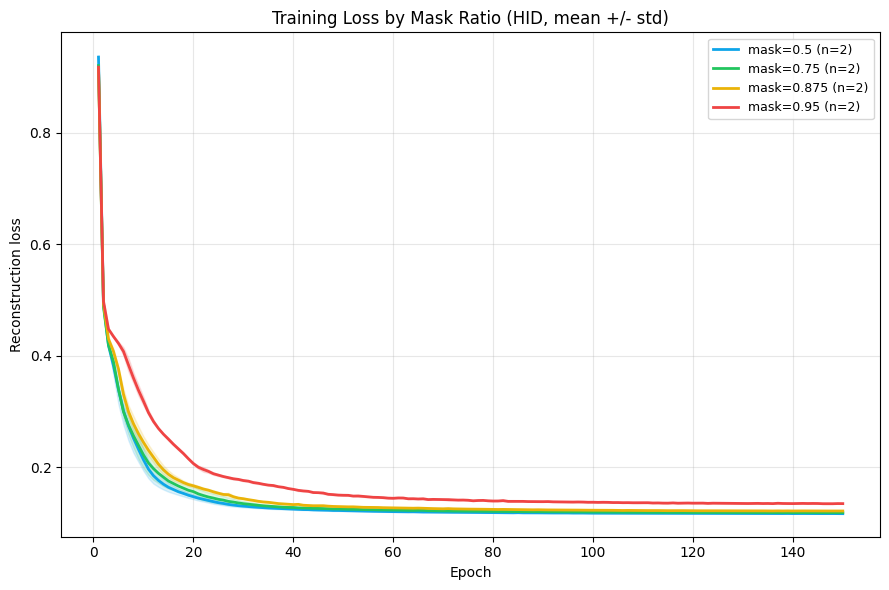

In [9]:
if ratio_groups:
    plot_loss_curve_by_group(ratio_groups, FIG_DIR, "hid_ratio_loss_curve.png",
                             "Training Loss by Mask Ratio (HID, mean +/- std)",
                             colors=GROUP_COLORS, group_label_fmt="mask={k}")

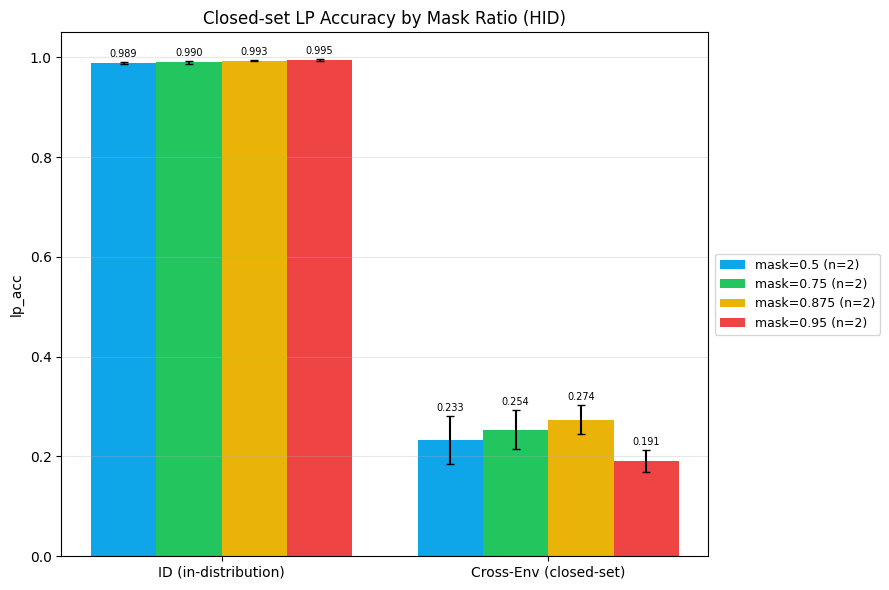

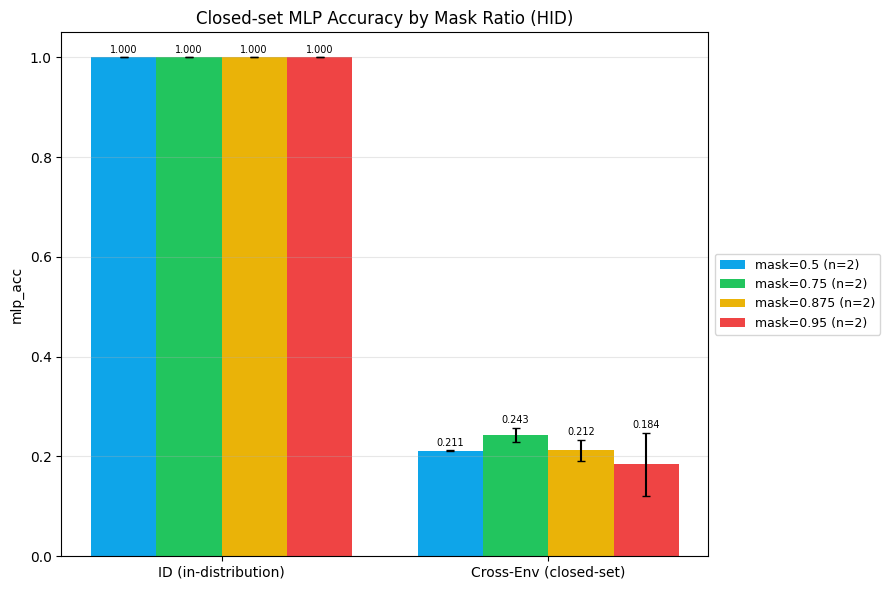

In [10]:
if ratio_groups:
    plot_closed_set_bar_by_group(ratio_groups, FIG_DIR, "hid_ratio_closedset_lp_acc.png",
                                 "Closed-set LP Accuracy by Mask Ratio (HID)",
                                 metric='lp_acc', colors=GROUP_COLORS, group_label_fmt="mask={k}")
    plot_closed_set_bar_by_group(ratio_groups, FIG_DIR, "hid_ratio_closedset_mlp_acc.png",
                                 "Closed-set MLP Accuracy by Mask Ratio (HID)",
                                 metric='mlp_acc', colors=GROUP_COLORS, group_label_fmt="mask={k}")

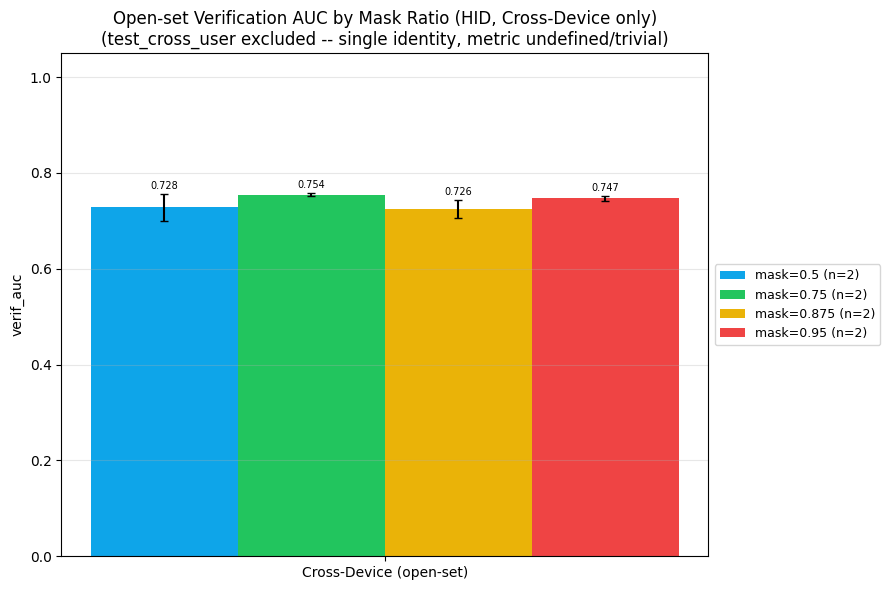

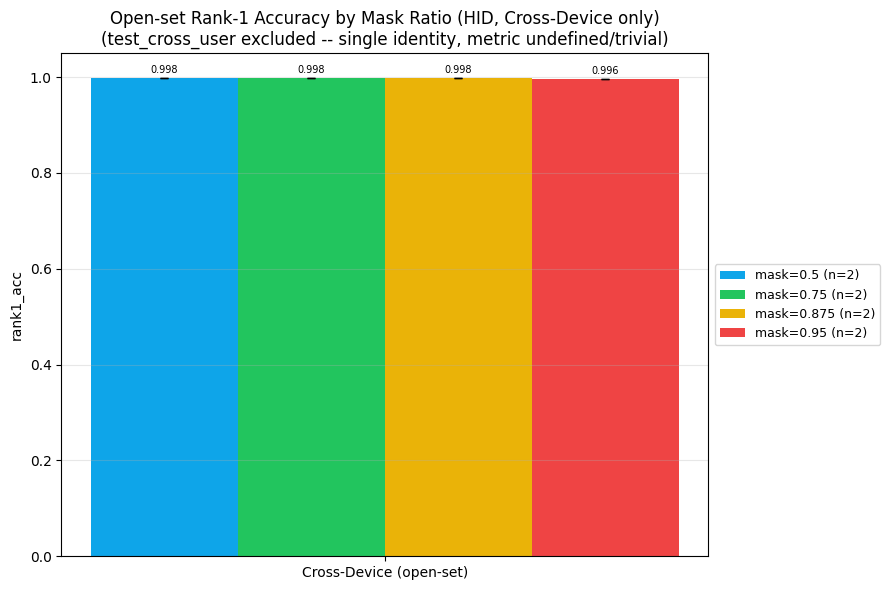

In [11]:
if ratio_groups:
    plot_openset_bar_by_group(ratio_groups, FIG_DIR, "hid_ratio_openset_verif_auc.png",
                              "Open-set Verification AUC by Mask Ratio (HID, Cross-Device only)",
                              metric='verif_auc', colors=GROUP_COLORS, group_label_fmt="mask={k}")
    plot_openset_bar_by_group(ratio_groups, FIG_DIR, "hid_ratio_openset_rank1.png",
                              "Open-set Rank-1 Accuracy by Mask Ratio (HID, Cross-Device only)",
                              metric='rank1_acc', colors=GROUP_COLORS, group_label_fmt="mask={k}")

## Section B -- Mask Strategy Ablation (enc12, mask_ratio=0.75)

In [12]:
STRATEGY_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
    "epochs": 150,
}
DEBUG = False

strategy_results = load_matching_results(RESULTS_DIR, STRATEGY_FILTERS, debug=DEBUG)
if not strategy_results:
    print("No mask-strategy files matched. Set DEBUG=True and re-run.")
    strategy_groups = {}
else:
    strategy_groups = group_by(strategy_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(strategy_results)} files across {len(strategy_groups)} strategies: "
          f"{ {k: len(v) for k, v in strategy_groups.items()} }")

Found 10 files across 5 strategies: {'2d': 2, 'freq': 2, 'mixed': 2, 'random': 2, 'time': 2}


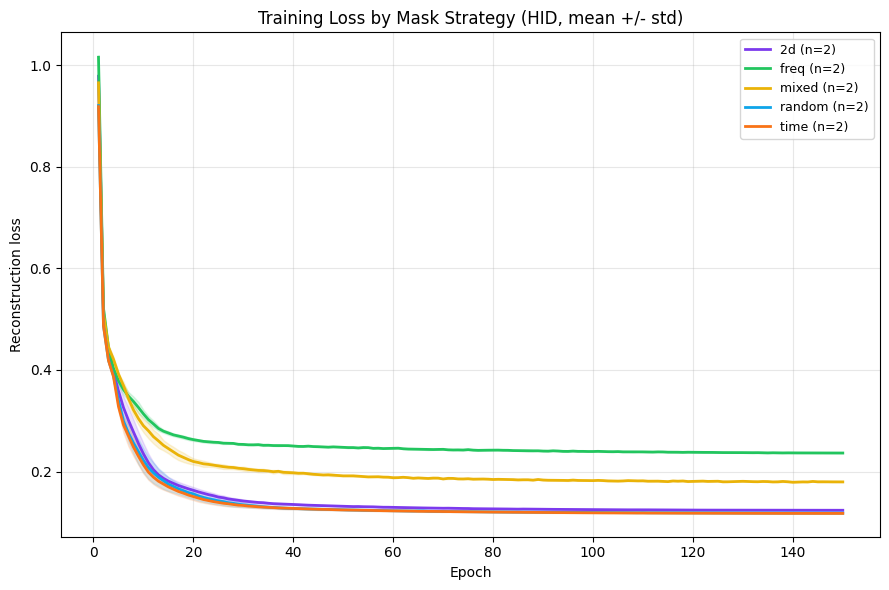

In [13]:
if strategy_groups:
    plot_loss_curve_by_group(strategy_groups, FIG_DIR, "hid_strategy_loss_curve.png",
                             "Training Loss by Mask Strategy (HID, mean +/- std)",
                             colors=GROUP_COLORS, group_label_fmt="{k}")

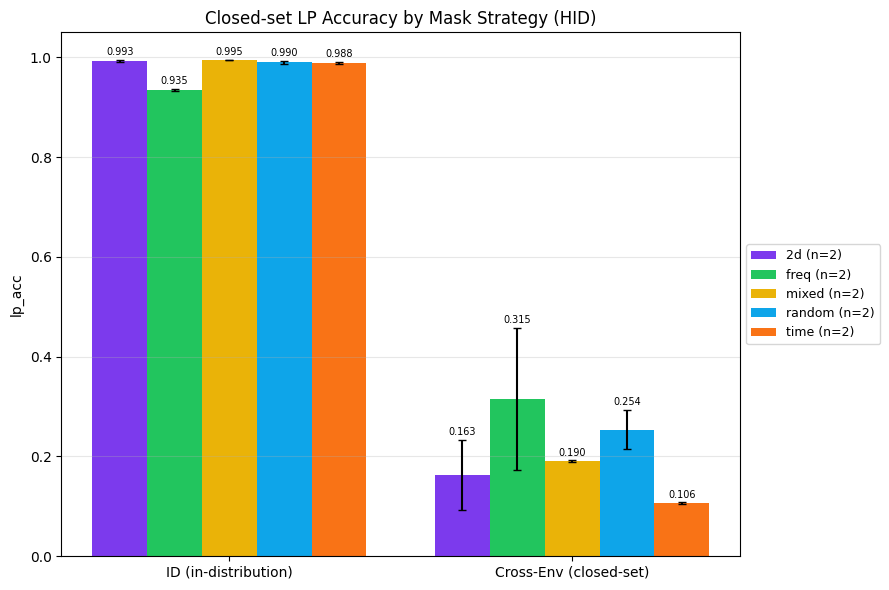

In [14]:
if strategy_groups:
    plot_closed_set_bar_by_group(strategy_groups, FIG_DIR, "hid_strategy_closedset_lp_acc.png",
                                 "Closed-set LP Accuracy by Mask Strategy (HID)",
                                 metric='lp_acc', colors=GROUP_COLORS, group_label_fmt="{k}")

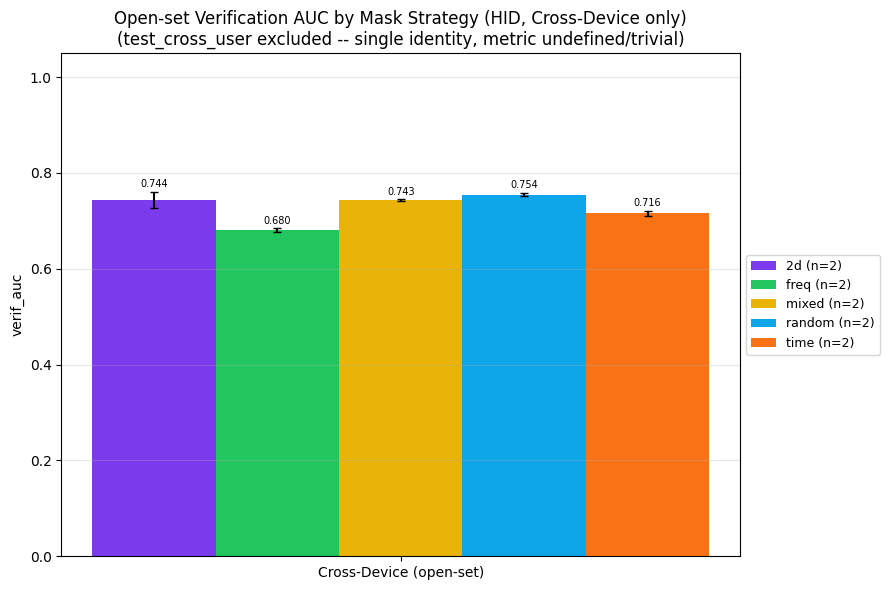

In [15]:
if strategy_groups:
    plot_openset_bar_by_group(strategy_groups, FIG_DIR, "hid_strategy_openset_verif_auc.png",
                              "Open-set Verification AUC by Mask Strategy (HID, Cross-Device only)",
                              metric='verif_auc', colors=GROUP_COLORS, group_label_fmt="{k}")

## Section C -- Patch Size Ablation (enc12, mask_ratio=0.75, mask_strategy=random)

In [16]:
PATCH_FILTERS = {
    "mask_ratio": 0.75,
    "mask_strategy": "random",
    "encoder_depth": 12,
    "epochs": 150,
}
DEBUG = False

patch_results = load_matching_results(RESULTS_DIR, PATCH_FILTERS, debug=DEBUG)
if not patch_results:
    print("No patch-size files matched. Set DEBUG=True and re-run.")
    patch_groups = {}
else:
    # group by patch_h (assumes square patches, patch_h==patch_w -- adjust key_fn if not)
    patch_groups = group_by(patch_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(patch_results)} files across {len(patch_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in patch_groups.items()} }")

Found 12 files across 6 patch sizes: {13: 2, 15: 2, 17: 2, 19: 2, 21: 2, 29: 2}


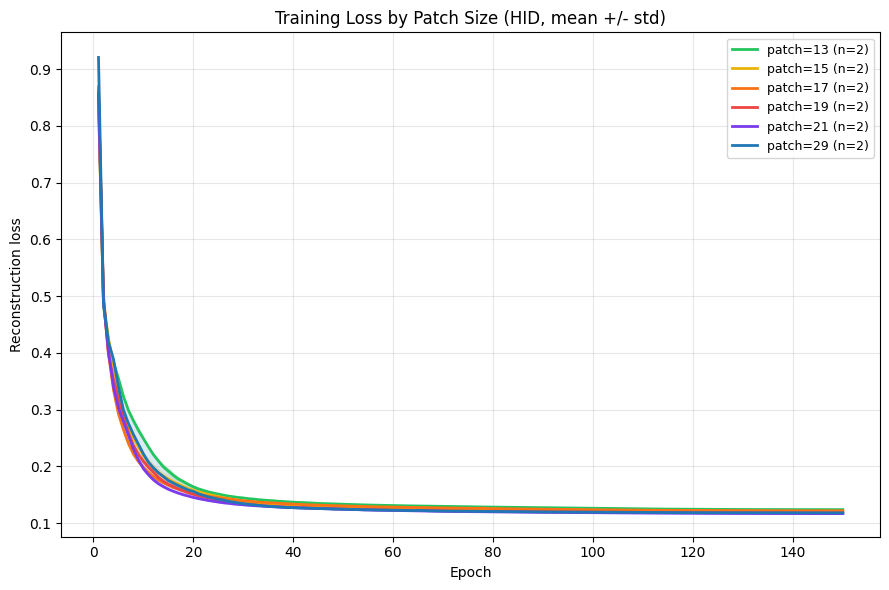

In [17]:
if patch_groups:
    plot_loss_curve_by_group(patch_groups, FIG_DIR, "hid_patch_loss_curve.png",
                             "Training Loss by Patch Size (HID, mean +/- std)",
                             colors=GROUP_COLORS, group_label_fmt="patch={k}")

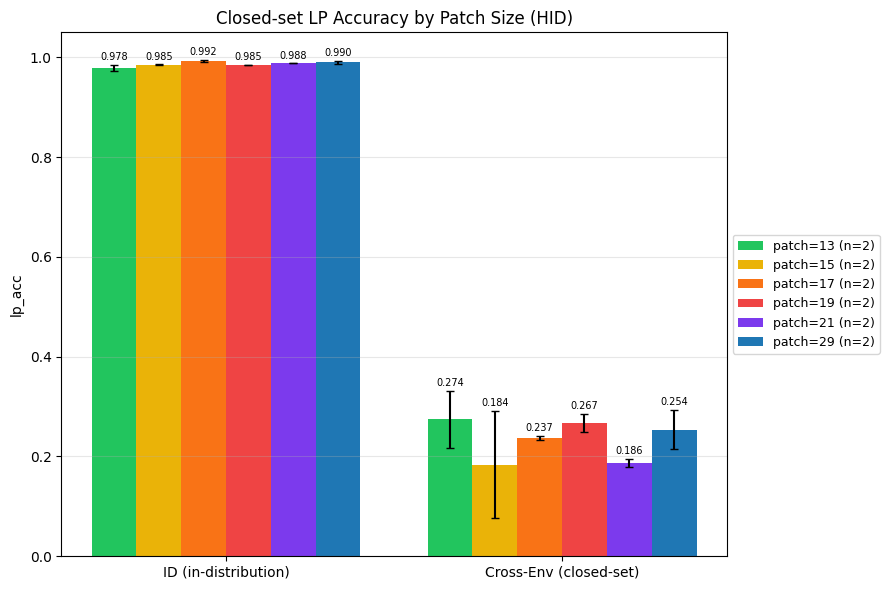

In [18]:
if patch_groups:
    plot_closed_set_bar_by_group(patch_groups, FIG_DIR, "hid_patch_closedset_lp_acc.png",
                                 "Closed-set LP Accuracy by Patch Size (HID)",
                                 metric='lp_acc', colors=GROUP_COLORS, group_label_fmt="patch={k}")

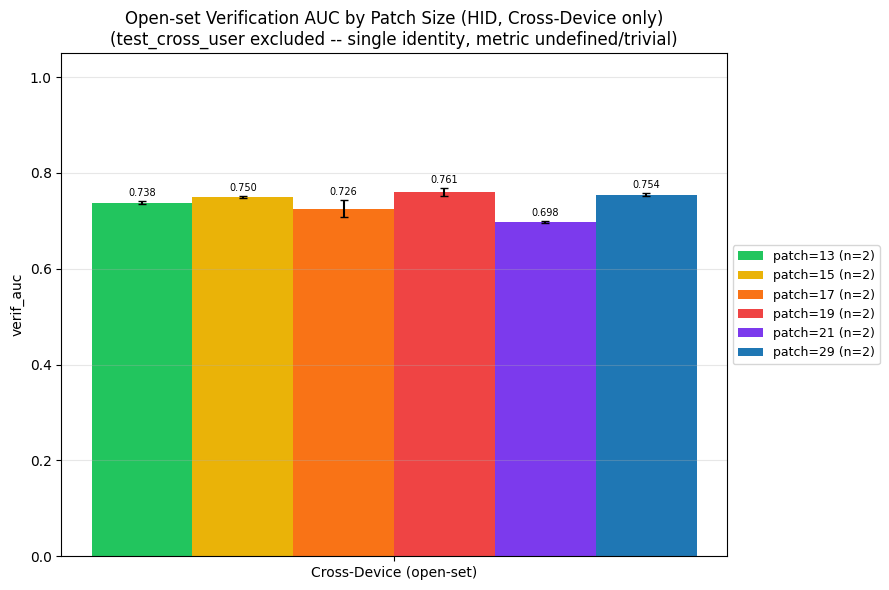

In [19]:
if patch_groups:
    plot_openset_bar_by_group(patch_groups, FIG_DIR, "hid_patch_openset_verif_auc.png",
                              "Open-set Verification AUC by Patch Size (HID, Cross-Device only)",
                              metric='verif_auc', colors=GROUP_COLORS, group_label_fmt="patch={k}")

## Notes / caveats

- **`test_cross_user` is excluded from open-set bar charts by default.** It contains only one identity (`U02`), so Rank-1 accuracy is trivially 100% regardless of embedding quality, and verification AUC/EER are undefined (no different-identity pairs exist within the split). Pass `include_trivial_split=True` to `plot_openset_bar_by_group` if you specifically want to see/annotate this, but don't use it to draw conclusions about generalization.
- **Verification AUC/EER are more trustworthy than Rank-1 for `test_cross_device`.** Rank-1 has been consistently near-ceiling (~99.7-99.9%) across every config tested so far regardless of mask ratio/strategy -- it isn't discriminating between configs. AUC (typically 0.70-0.77 range) and EER show more meaningful spread.
- **Run-to-run variance is substantial for HID, more so than HAR.** The mask ratio ablation showed seed42 and seed43 giving *opposite* rankings for mask=0.5 vs mask=0.875 (a ~0.05 AUC swing) -- don't trust any single-seed result. Every group above should have `n>=2`; check the printed `n=` in each legend and the `[warn]` messages for inconsistent-n groups before drawing conclusions.
- **`DEBUG=True`** in any filter cell prints a per-file `[match]` / `[skip: reason]` line -- fastest way to diagnose why an expected file wasn't picked up (wrong `mask_ratio`, missing `patch_h`, wrong `encoder_depth`, etc.).